In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_t = np.arange(-10, 10, 0.1)
X_t = X_t.reshape(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)

plt.plot(X_t, Y_t)
plt.show()

In [ ]:
X_t.shape

In [ ]:
n_neurons = 500

from RNN import *

rnn = RNN(X_t, n_neurons)

In [ ]:
rnn.Y_hat.shape

In [ ]:
rnn.H.__getitem__(0).shape

In [ ]:
n_neurons = 500

from RNN import *

rnn = RNN(X_t, n_neurons)

Y_hat = rnn.Y_hat
H = rnn.H
T = rnn.T

ht = H[0]

for t, xt in enumerate(X_t):
    xt = xt.reshape(1, 1)

    [ht, y_hat_t, out] = rnn.forward(xt, ht)

    H[t + 1] = ht
    Y_hat[t] = y_hat_t

dY = Y_hat - Y_t
L = 0.5 * np.dot(dY.T, dY) / T

plt.plot(X_t, Y_t)
plt.plot(X_t, Y_hat)
plt.legend(['y', '$\hat{y}$'])
plt.show()

for h in H:
    plt.plot(np.arange(20), h[0:20], 'k-', linewidth=1, alpha=0.05)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_t = np.arange(-10, 10, 0.1)
X_t = X_t.reshape(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)

plt.plot(X_t, Y_t)
plt.show()

n_neurons = 500

from RNN import *

rnn = RNN(X_t, n_neurons, Tanh())
rnn.forward()

Y_hat = rnn.Y_hat
H = rnn.H
T = rnn.T

dY = Y_hat - Y_t
L = 0.5 * np.dot(dY.T, dY) / T

plt.plot(X_t, Y_t)
plt.plot(X_t, Y_hat)
plt.legend(['y', '$\hat{y}$'])
plt.show()

for h in H:
    plt.plot(np.arange(20), h[0:20], 'k-', linewidth=1, alpha=0.05)

In [ ]:
rnn.ACT[5]

In [ ]:
rnn.ACT[5].inputs

### test 4

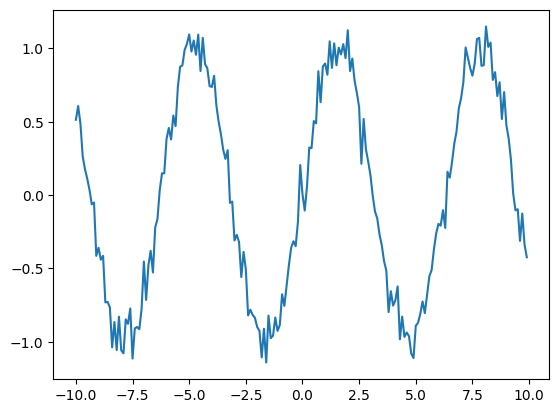

C:\Users\moham\AppData\Local\Temp\ipykernel_5508\2494321645.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(L))


1.3810762773543563


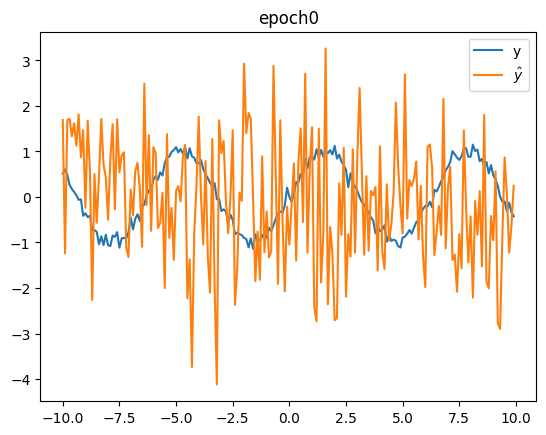

9.058951282805195


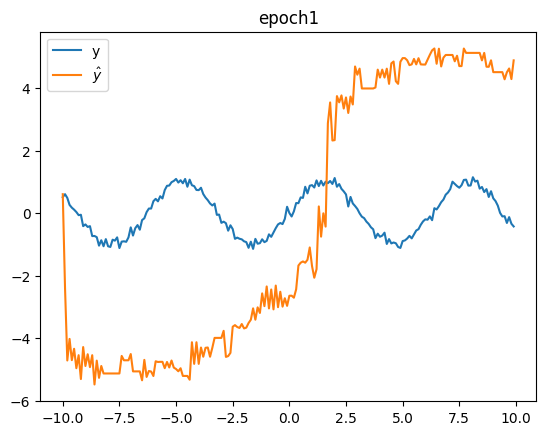

0.6783022654324118


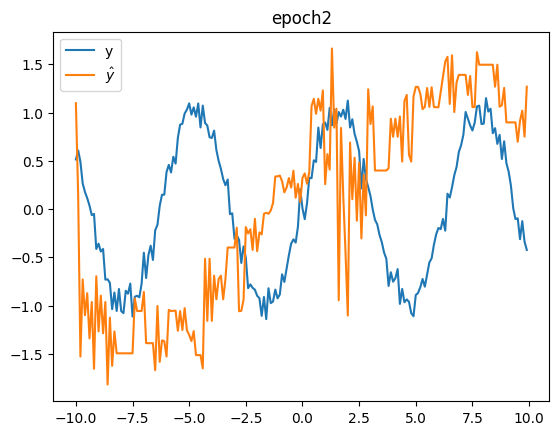

0.41797896419652447


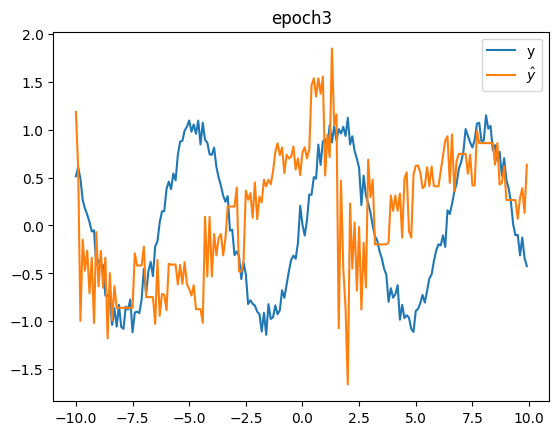

0.3924867770724225


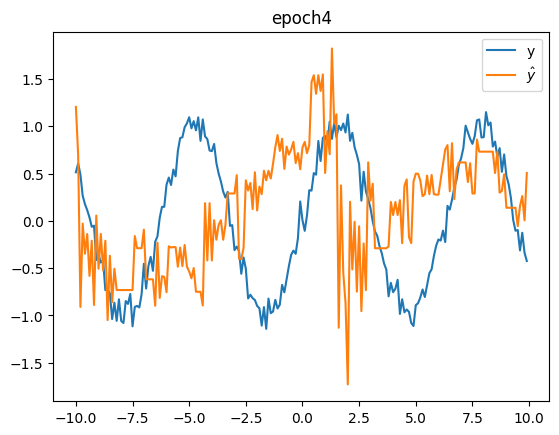

0.3760503874760806


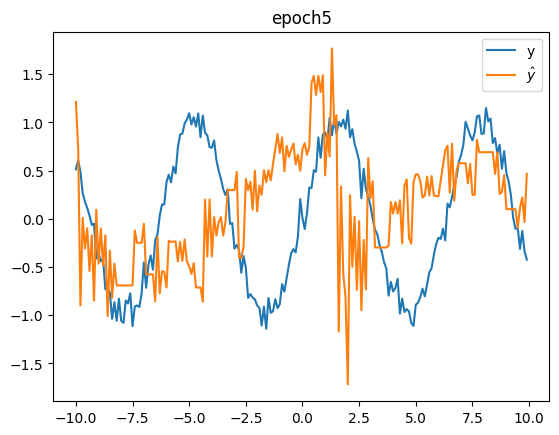

0.3618465469345083


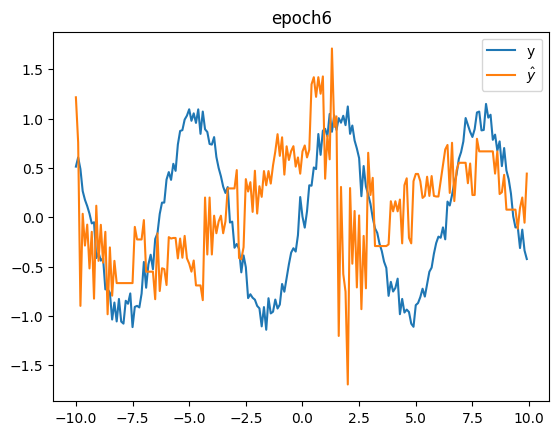

0.34936935729844415


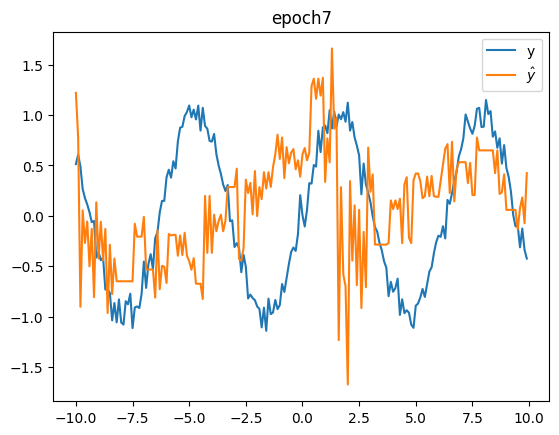

0.33834418507884123


KeyboardInterrupt: 

In [26]:
import numpy as np
import matplotlib.pyplot as plt

X_t = np.arange(-10, 10, 0.1)
X_t = X_t.reshape(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)

plt.plot(X_t, Y_t)
plt.show()

from RNN import *

n_neurons = 500
rnn = RNN(X_t, n_neurons, Tanh())
T = rnn.T
n_epoch = 200
e = 1e-5

for n in range(n_epoch):
    rnn.forward()
    Y_hat = rnn.Y_hat
    dY = Y_hat - Y_t
    L = 0.5 * np.dot(dY.T, dY) / T
    print(float(L))
    rnn.backward(dY)

    rnn.Wx -= e * rnn.dWx
    rnn.Wy -= e * rnn.dWy
    rnn.Wh -= e * rnn.dWh
    rnn.biases -= e * rnn.dbiases

    plt.plot(X_t, Y_t)
    plt.plot(X_t, Y_hat)
    plt.legend(['y', '$\hat{y}$'])
    plt.title('epoch' + str(n))
    plt.show()

# test 5

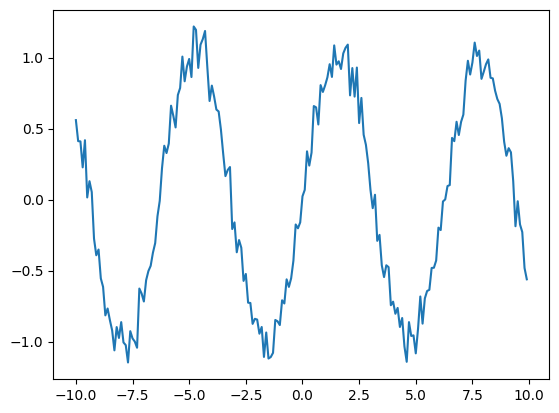

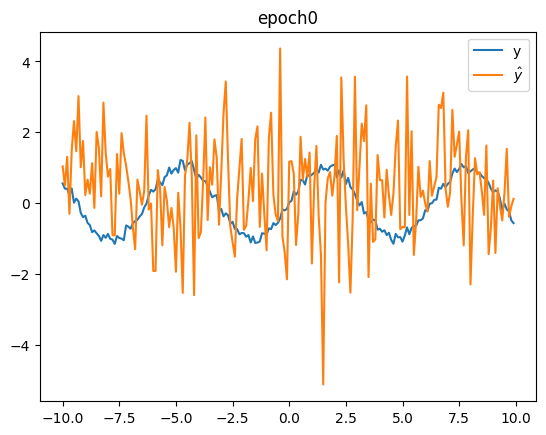

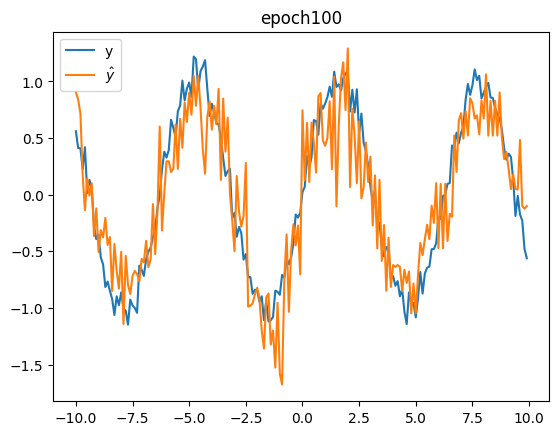

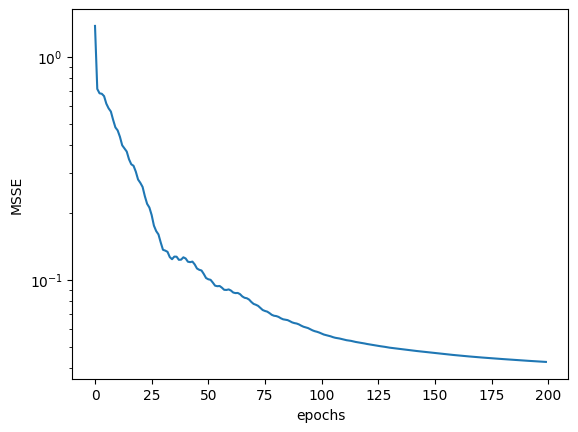

In [34]:
import numpy as np
import matplotlib.pyplot as plt

X_t = np.arange(-10, 10, 0.1)
X_t = X_t.reshape(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)

plt.plot(X_t, Y_t)
plt.show()

from RNN import *
# from SGD import Optimizer_SGD
# print(Optimizer_SGD)
n_neurons = 500
rnn = RNN(X_t, n_neurons, Tanh())
# a = Optimizer_SGD()
optimizer = Optimizer_SGD(learning_rate=1e-5,decay=0.01, momentum=0.95)
T = rnn.T
n_epochs = 200
e = 1e-5

Monitor = np.zeros((n_epochs, 1))

for n in range(n_epoch):
    rnn.forward()
    Y_hat = rnn.Y_hat
    dY = Y_hat - Y_t
    L = 0.5 * np.dot(dY.T, dY) / T

    # print(float(L))
    Monitor[n] = L

    rnn.backward(dY)

    optimizer.pre_update_params()
    optimizer.update_params(rnn)
    optimizer.post_update_params()

    #done by the optimizer
    # rnn.Wx -= e * rnn.dWx
    # rnn.Wy -= e * rnn.dWy
    # rnn.Wh -= e * rnn.dWh
    # rnn.biases -= e * rnn.dbiases

    if n % 100 == 0:
        plt.plot(X_t, Y_t)
        plt.plot(X_t, Y_hat)
        plt.legend(['y', '$\hat{y}$'])
        plt.title('epoch' + str(n))
        plt.show()

plt.plot(range(n_epochs), Monitor)
# plt.plot(X_t, Y_hat)
plt.xlabel('epochs')
plt.ylabel('MSSE')
plt.yscale('log')
# plt.title('epoch' + str(n))
plt.show()

## test 6

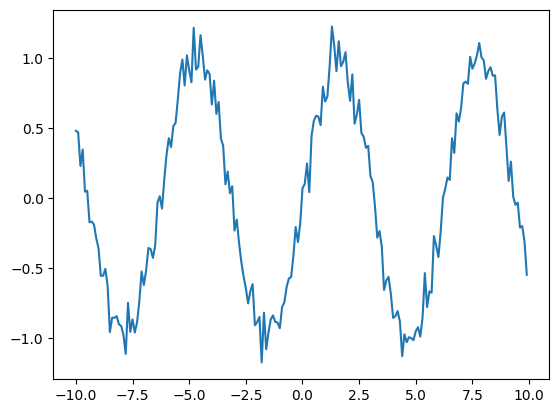

RNN is running...


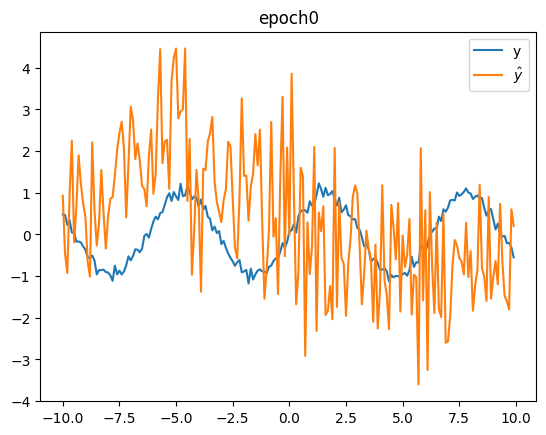

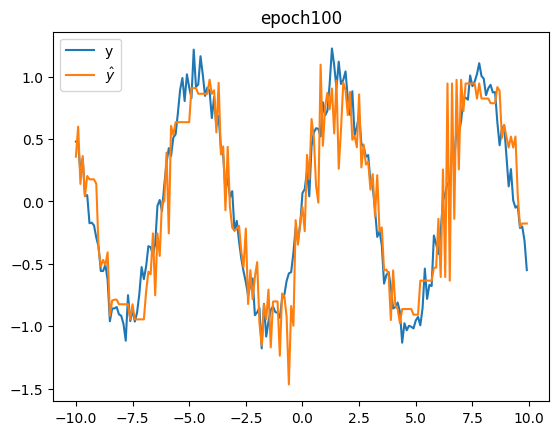

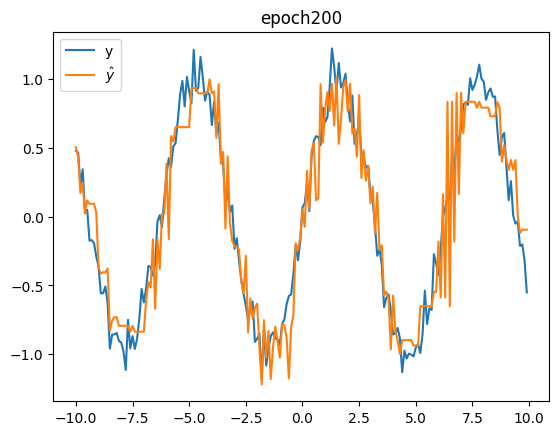

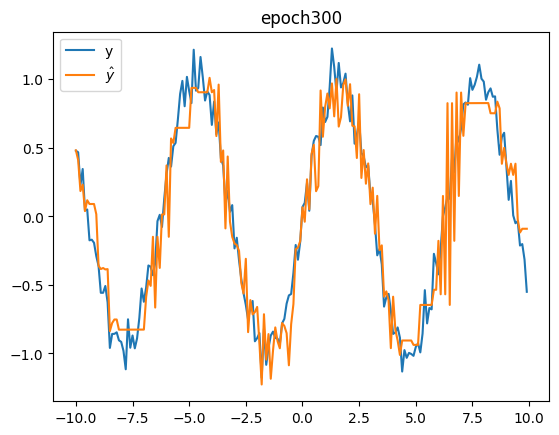

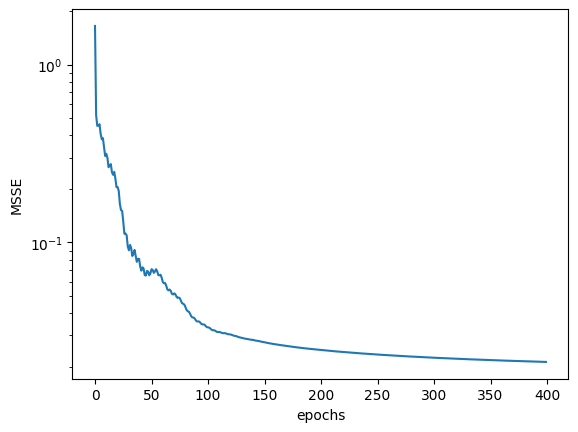

Done!, MSSE:0.021


In [3]:
import matplotlib.pyplot as plt
import numpy as np
X_t = np.arange(-10, 10, 0.1)
X_t = X_t.reshape(len(X_t), 1)
Y_t = np.sin(X_t) + 0.1 * np.random.randn(len(X_t), 1)

plt.plot(X_t, Y_t)
plt.show()

from RNN import *
rnn = RunMyRNN(X_t, Y_t, Tanh())